# Лабораторная работа №2. Дискретные LTI системы.

Курс: Лаборатория цифровой обработки сигналов (ФРКТ, ФАКТ), осенний семестр.

LMS: https://lms.mipt.ru/course/view.php?id=4561&type=lab

* В имени этого файла заменить familyname на Ваши фамилию и имя, либо только фамилию.  
* Задачи 2.1, 3.1(А), 3.2 содержат практическую часть, выполняемую с использованием осциллографа. 
* Задача 4.1 предполагает работу с системой Engee либо РДС. Информацию о них можно найти на следующих страницах. 
* * Engee https://engee.com (для регистрации использовать почтовый аккаунт @phystech.edu).
* * РДС https://www.ipu.ru/science/applied-research/software/calculation-of-dynamic-systems . 
* В некоторых задачах варианты определяются первой буквой Вашей фамилии.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile
from scipy import signal
from IPython.display import Audio


In [2]:
def osc_read_txt(file, const_level=0):
    f = open(file)
    str1 = f.read().split('\n')
    f.closed
    dt, unit = str1[1].replace(',', '.').split(' ')[3:5]
    dt = float(dt)
    if unit=='uS':
        dt*=1e-6
    elif unit=='nS':
        dt*=1e-9
    elif unit=='mS':
        dt*=1e-3
    fs = int(1.0 / dt)
    dv, unit = str1[2].replace(',', '.').split(' ')[3:5]
    dv=float(dv)
    if unit=='mV':
        dv*=1e-3

    zero_level= int(str1[3].split(' ')[3])
    str_num = len(str1)
    signal_lev = np.empty(shape=(str_num-8), dtype=float)
    for k, u in enumerate(range(7, str_num-1, 1)):
        data = str1[u].split()
        signal_lev[k]=(int(data[1])-zero_level)*dv-const_level
    return fs, signal_lev


In [3]:
# Для использования backend matplotlib inline/widget/notebook, раскомментируйте соответствующую строку ниже.
# Установка widget: pip install --upgrade jupyterlab ipympl
# %matplotlib inline
# %matplotlib notebook
%matplotlib widget


Модуль 1. Линейная дискретная свертка.

* Задача 1.1. Линейная дискретная свертка прямоугольных окон.

* Задача 1.2. Эффективное вычисление свертки.

Модуль 2. Характеристики LTI систем.

* Задача 2.1. Фильтр скользящего среднего.

* Задача 2.2. Двухкаскадный фильтр.

Модуль 3. Аппроксимация идеальных частотно-избирательных фильтров и явление Гиббса.

* Задача 3.1. Явление Гиббса для каузальной аппроксимации ИФНЧ.

* Задача 3.2.  Аппроксимация фильтра с заданной частотной характеристикой с помощью ДВПФ.   

Модуль 4. Графическое моделирование динамических систем.

* Задача 4.1. Моделирование цифрового фильтра в Engee/РДС.

# Модуль 1. Линейная дискретная свертка.

## Задача 1.1. Линейная дискретная свертка прямоугольных окон.

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|    $M$    | 4 | 5 | 6 | 4 | 5 | 6 | 8 | 7 | 8 | 7 |

Вычислить аналитически линейную дискретную свертку двух одинаковых последовательностей $x[k]$ и $h[k]$, таких, что 
$x[k]=h[k]=\sum_{m=0}^{M-1}\mathbf{1} [k-m], $
где $M$ соответствует варианту, непосредственно воспользовавшись формулой линейной дискретной свертки
$y[k]=\sum_{m=-\infty}^{\infty} x[m] h[k-m].$

Проверить результаты с помощью моделирования, воспользовавшись функцией `signal.convolve`

#### Аналитическое вычисление при $M = 8$:

$$ \text{Так как } x[k]=h[k]= \sum_{m=0}^{7}\mathbf{1} [k-m] = \underbrace{\{1, 1, 1, 1, 1, 1, 1, 1\}}_{k=0..7}, \text{ то}$$

$$ \mathbf{y[0]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[0 - m] = x[0] \cdot h[0] = 1 \cdot 1 = \mathbf{1} $$

$$ \mathbf{y[1]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[1 - m] = x[0] \cdot h[1] + x[1] \cdot h[0] = 1 + 1 = \mathbf{2} $$

$$ \mathbf{y[2]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[2 - m] = x[0]h[2] + x[1]h[1] + x[2]h[0] = 1 + 1 + 1 = \mathbf{3} $$

$$ \mathbf{y[3]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[3 - m] = x[0]h[3] + \dots + x[3]h[0] = 4 \cdot 1 = \mathbf{4} $$

$$ \mathbf{y[4]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[4 - m] = x[0]h[4] + \dots + x[4]h[0] = 5 \cdot 1 = \mathbf{5} $$

$$ \mathbf{y[5]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[5 - m] = x[0]h[5] + \dots + x[5]h[0] = 6 \cdot 1 = \mathbf{6} $$

$$ \mathbf{y[6]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[6 - m] = x[0]h[6] + \dots + x[6]h[0] = 7 \cdot 1 = \mathbf{7} $$

$$ \mathbf{y[7]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[7 - m] = x[0]h[7] + x[1]h[6] + \dots + x[7]h[0] = 8 \cdot 1 = \mathbf{8} $$

$$ \mathbf{y[8]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[8 - m] = x[1]h[7] + x[2]h[6] + \dots + x[7]h[1] = 7 \cdot 1 = \mathbf{7} $$

$$ \mathbf{y[9]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[9 - m] = x[2]h[7] + \dots + x[7]h[2] = 6 \cdot 1 = \mathbf{6} $$

$$ \mathbf{y[10]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[10 - m] = x[3]h[7] + \dots + x[7]h[3] = 5 \cdot 1 = \mathbf{5} $$

$$ \mathbf{y[11]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[11 - m] = x[4]h[7] + \dots + x[7]h[4] = 4 \cdot 1 = \mathbf{4} $$

$$ \mathbf{y[12]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[12 - m] = x[5]h[7] + x[6]h[6] + x[7]h[5] = 3 \cdot 1 = \mathbf{3} $$

$$ \mathbf{y[13]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[13 - m] = x[6]h[7] + x[7]h[6] = 1 + 1 = \mathbf{2} $$

$$ \mathbf{y[14]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[14 - m] = x[7] \cdot h[7] = \mathbf{1} $$

$$ \mathbf{y[15]} = \sum_{m=-\infty}^{\infty} x[m] \cdot h[15 - m] = \mathbf{0} = \mathbf{y[k]} \text{ при } k > 14 $$


Моделирование:

In [4]:
M = 8

x=np.array([1] * M)
h=np.array([1] * M)

y=signal.convolve(x, h)
print(*y)


1 2 3 4 5 6 7 8 7 6 5 4 3 2 1


## Задача 1.2. Эффективное вычисление свертки.


| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|     $m$    |   17   |   18   |   17   |   18   |   17   |   18   |   17   |   18   |   17   |   18   |
| $n_0$ |  128  |  32  |  256  |  64  |  512  |  1024  |  230  |  325  |  501  |  1000  |

Даны последовательности отсчетов

$ x[k]= \cos(2\pi kn_0/N) $

$ h[k]= \sin(2\pi kn_0/N) $

где $n_0$, $N=2^m$ взять из таблицы сверху в соответствии с вариантом и $k$ пробегает значения от $0$ до $N-1.$  
Вычислить их линейную дискретную свертку c помощью `signal.convolve()` двумя способами: с помощью прямого вычисления по формуле свёртки и с использованием алгоритма БПФ.  
Сравнить вычислительную эффективность, сделать вывод. 

P.S. На вычисление свертки по формуле может потребоваться значительное количество времени. 



In [5]:
m = 17
n_0 = 501

N = pow(2, m)
k = np.arange(N)

x = np.cos(2 * np.pi * k * n_0 / N)
h = np.sin(2 * np.pi * k *  n_0 / N)


Вычисление свертки по формуле
$$y[k]=\sum_{m=-\infty}^{\infty} x[m] h[k-m].$$

In [6]:
%timeit signal.convolve(x, h, method="direct")
y_classic = signal.convolve(x, h, method="direct")

print(y_classic)


2.15 s ± 663 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
[ 0.          0.02401408  0.07202146 ... -0.14387679 -0.07198684
 -0.02400715]


Вычисление свертки с использованием алгоритма БПФ

In [7]:
%timeit signal.convolve(x, h, method="fft")
y_fast = signal.convolve(x, h, method="fft")

print(y_fast)


15.4 ms ± 467 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
[-2.45039853e-12  2.40140781e-02  7.20214587e-02 ... -1.43876785e-01
 -7.19868408e-02 -2.40071529e-02]


In [8]:
print(f"Max error: {max(abs(y_classic - y_fast)):.1e}")


Max error: 4.4e-11


# Модуль 2. Характеристики LTI систем.






## Задача 2.1. Фильтр скользящего среднего.

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|$M_1$|  9 | 14 | 13 |  9 | 12 |  11 | 14 | 13 |  9 | 12 |
|$M_2$| 29 | 50 | 40 | 24 | 50 |  45 | 50 | 40 | 24 | 50 |
| $K$ | 35 | 63 | 57 | 35 | 63 |  55 | 63 | 57 | 35 | 63 |
| $N$ |100 |140 |130 |100 |140 | 115 |140 | 130 | 100 | 140 |

Рассмотрите фильтр скользящего среднего

$$y[k]=\dfrac{1}{M}\sum_{m=0}^{M-1} x[k-m]$$

для $M = M_1$ и $M = M_2$ (из таблицы): 

* Определите и изобразите импульсную характеристику $h[k]$ фильтра.

* Вычислите с помощью `signal.convolve` отклик $y[k]$ фильтра на входное воздействие вида
$$ x_{noise}[k] = \sin(2\pi k / K) + \varepsilon[k], 0\le k\le N-1.$$
где $K,\;N$ — соответствующие числа из таблицы, $\varepsilon[k]$ — белый гаусовский шум (`np.random.normal(mu, sigma, N)`) с нулевым среднем `mu=0` и  среднеквадратическим отклонением $\sigma=0.1$ (`sigma=0.1`).  
* Сравните сигналы $x_{noise}[k]$, $y[k]$ и 
$$ x[k] = \sin(2\pi k / K), 0\le k\le N-1.$$
* Определите и изобразите амплитудно-частотную характеристику (АЧХ) $|H(\nu)|$ фильтра. Как выбор $M$ влияет на результат фильтрации отрезка гармонического сигнала?

**Практическая часть (сглаживание сигнала датчика).**

Примените фильтр скользящего среднего для сглаживания шумов в записях сигналов с двух различных аналоговых датчиков. При этом один из сигналов может быть взят из первой лабораторной работы (задача 1.1). Коэффициент $M$ подобрать самостоятельно. 
* Сделайте предположения о причинах возникновения шума в измерениях. 
* Обоснуйте выбор коэффициента $M$ для каждого из двух случаев.



[]

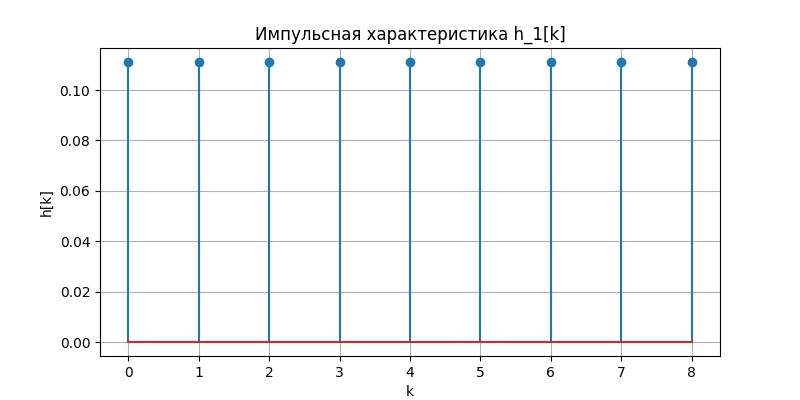

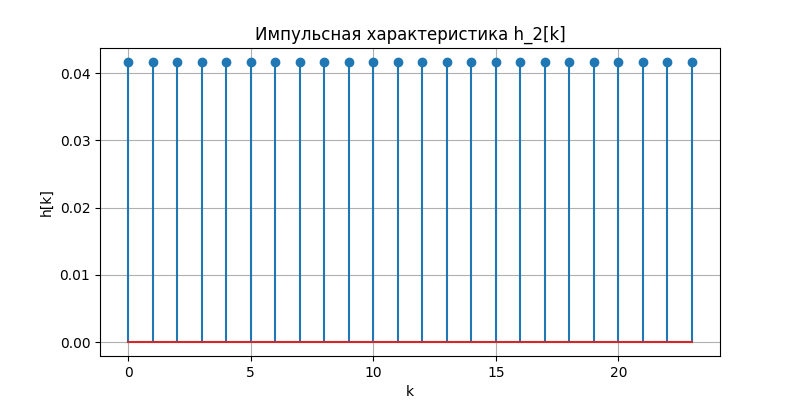

In [9]:
M_1 = 9
M_2 = 24
K = 35
N = 100

k_1 = np.arange(M_1)
k_2 = np.arange(M_2)
h_1 = np.ones(M_1) / M_1
h_2 = np.ones(M_2) / M_2

plt.figure(figsize=[8, 4])
plt.title("Импульсная характеристика h_1[k]")
plt.stem(k_1, h_1)
plt.grid()
plt.xlabel("k")
plt.ylabel("h[k]")
plt.plot()

plt.figure(figsize=[8, 4])
plt.title("Импульсная характеристика h_2[k]")
plt.stem(k_2, h_2)
plt.grid()
plt.xlabel("k")
plt.ylabel("h[k]")
plt.plot()


In [10]:
k = np.arange(N)

x_1 = np.sin(2 * np.pi * k / K) + np.random.normal(0, 0.1, N)
y_1 = signal.convolve(x_1, h_1)

x_2 = np.sin(2 * np.pi * k / K) + np.random.normal(0, 0.1, N)
y_2 = signal.convolve(x_2, h_2)


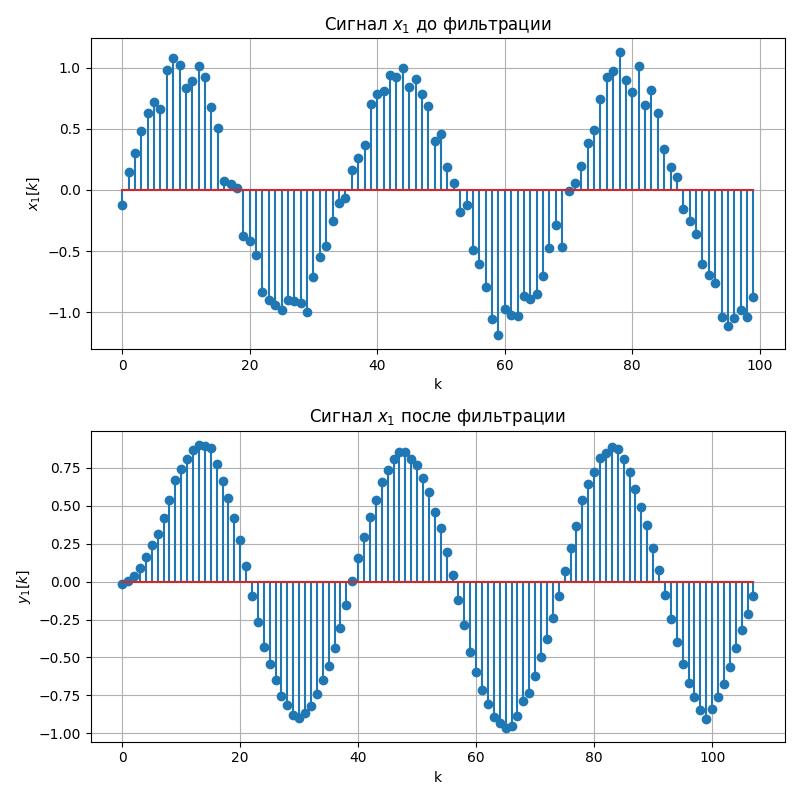

In [11]:
plt.figure(figsize=[8, 8], dpi=100)
plt.subplot(2, 1, 1)
plt.title(r"Сигнал $x_1$ до фильтрации")
plt.stem(k, x_1)
plt.grid()
plt.ylabel(r"$x_1[k]$")
plt.xlabel("k")

plt.subplot(2, 1, 2)
plt.title(r"Сигнал $x_1$ после фильтрации")
plt.stem(np.arange(y_1.size), y_1)
plt.ylabel(r"$y_1[k]$")
plt.xlabel("k")
plt.grid()
plt.tight_layout()


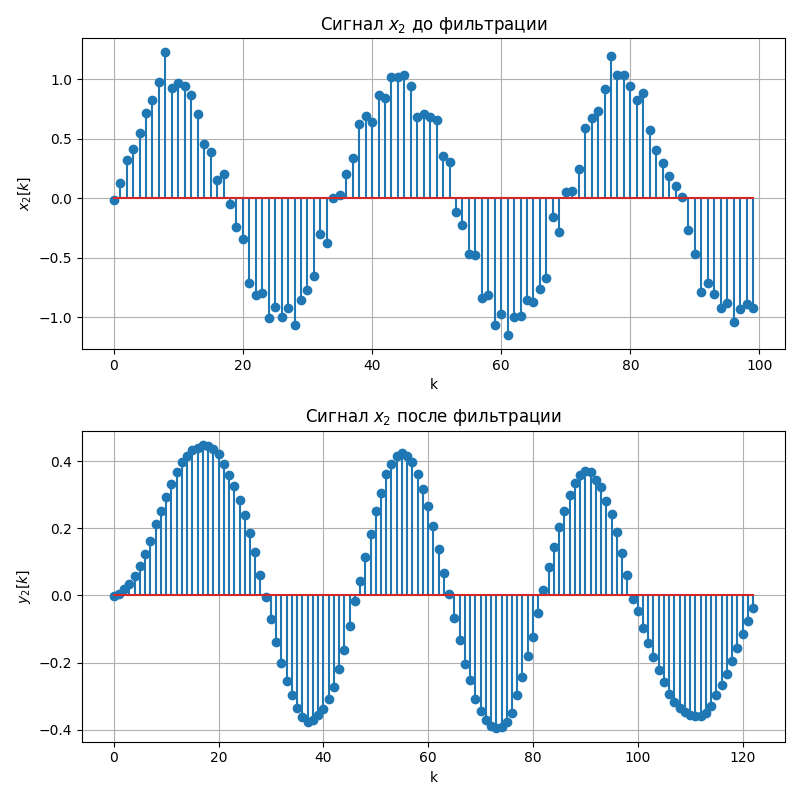

In [12]:
plt.figure(figsize=[8, 8], dpi=100)
plt.subplot(2, 1, 1)
plt.title(r"Сигнал $x_2$ до фильтрации")
plt.stem(k, x_2)
plt.grid()
plt.ylabel(r"$x_2[k]$")
plt.xlabel("k")

plt.subplot(2, 1, 2)
plt.title(r"Сигнал $x_2$ после фильтрации")
plt.stem(np.arange(y_2.size), y_2)
plt.ylabel(r"$y_2[k]$")
plt.xlabel("k")
plt.grid()
plt.tight_layout()


In [13]:
def dtft(x: np.array, M: int = 2048) -> tuple[np.array, np.array]:
    return (
        np.arange(M)/M - 0.5,
        np.fft.fftshift(np.fft.fft(x, M))
    )

def plot_filter_dtft(M: int, h: np.array) -> None:
    nu, H = dtft(h)

    plt.figure(figsize=[9, 5])
    plt.subplot(2, 1, 1)
    plt.title(f"АЧХ и ФЧХ фильтра скользящего среднего в случае M={M}")
    plt.plot(nu, abs(H), 'g')
    plt.xlabel(r"$\nu$")
    plt.ylabel(r"$|H(\nu)|$")
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(nu, np.angle(H))
    plt.ylabel(r"$\varphi(\nu)$")
    plt.xlabel(r"$\nu$")
    plt.grid()
    plt.tight_layout()


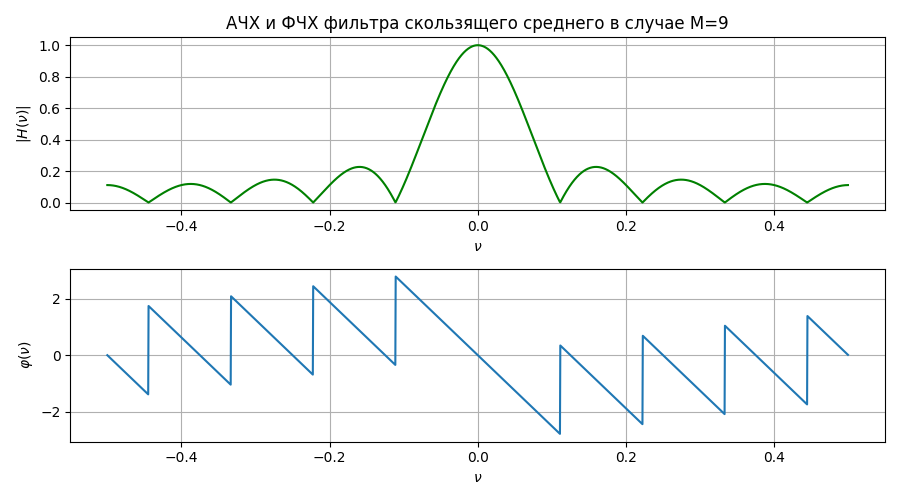

In [14]:
plot_filter_dtft(M_1, h_1)


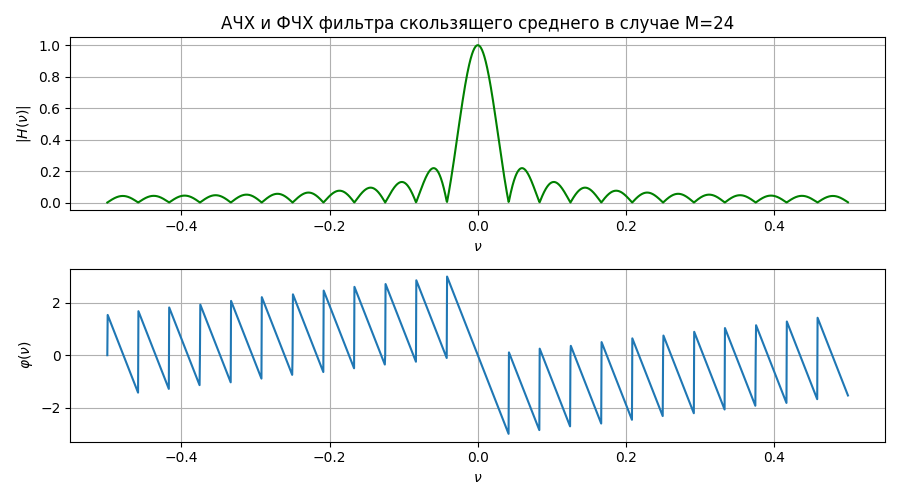

In [15]:
plot_filter_dtft(M_2, h_2)


Увеличение порядка фильтра M приводит к увеличению искажений отфильтрованного сигнала.

#### Практическая часть:

In [16]:
def h(M):
    return np.ones(M) / M


Джойстик

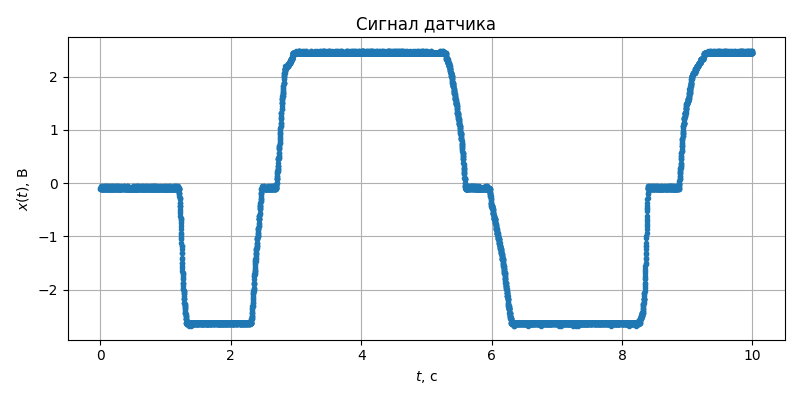

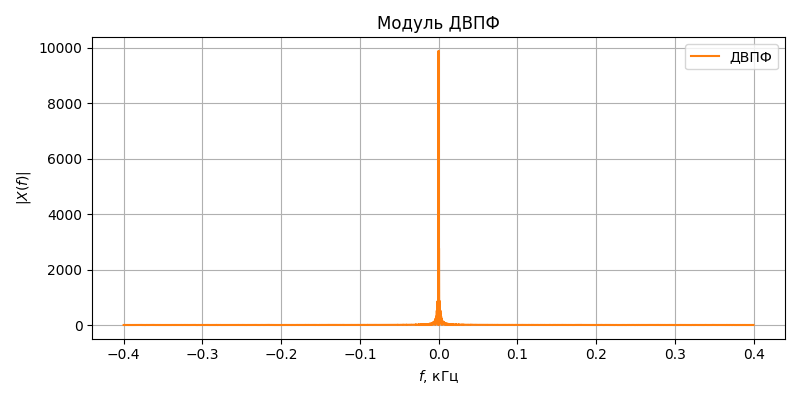

In [17]:
file_name = "Data/joystick.txt"

fs_1, x_1 = osc_read_txt(file=file_name)
x_1 = x_1 - x_1.mean()

plt.figure(figsize=[8, 4])
plt.title("Сигнал датчика")
k = np.arange(len(x_1))
plt.plot(k/fs_1, x_1, '.-')
plt.grid()
plt.xlabel("$t$, c")
plt.ylabel("$x(t)$, В")
plt.tight_layout()
plt.show()

# Вычисление ДВПФ
X_1_dtft = np.fft.fftshift(np.fft.fft(x_1))
f_1_dtft = np.fft.fftshift(np.fft.fftfreq(X_1_dtft.shape[0], d=1.0/fs_1))

# Модуль ДВПФ измерений с осциллографа.
plt.figure(figsize=[8, 4])
k = np.arange(len(x_1))
plt.plot(f_1_dtft/1e3, abs(X_1_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()


In [18]:
M = 50
y_1 = signal.convolve(x_1, h(M))
y_1


array([-0.00170984, -0.00404469, -0.00637953, ...,  0.14737047,
        0.09783031,  0.04891516])

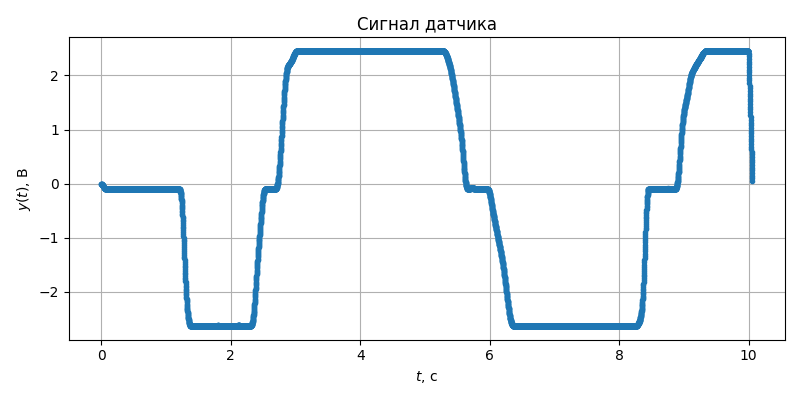

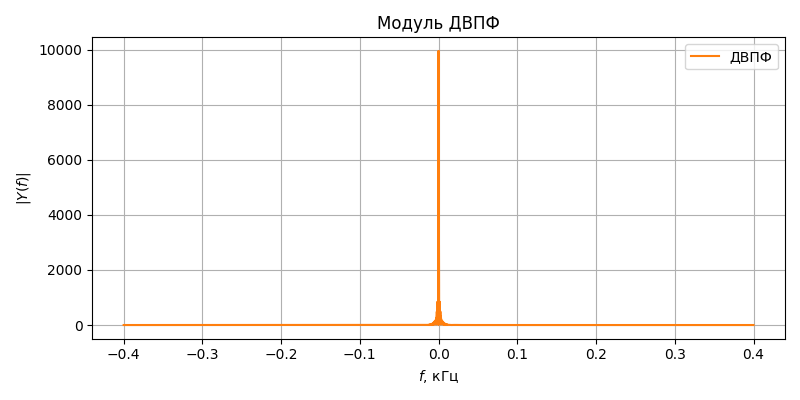

In [19]:
Y_1_dtft=scipy.fft.fftshift(scipy.fft.fft(y_1))
nu = -0.5 + np.linspace(0, 1, num=y_1.size)
Y_1_dtft

plt.figure(figsize=[8, 4])
plt.title("Сигнал датчика")
k = np.arange(len(y_1))
plt.plot(k/fs_1, y_1, '.-')
plt.grid()
plt.xlabel(r"$t$, c")
plt.ylabel(r"$y(t)$, В")
plt.tight_layout()
plt.show()

plt.figure(figsize=[8, 4])
k = np.arange(len(x_1))
plt.plot(nu*fs_1/1e3, abs(Y_1_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel(r"$f$, кГц")
plt.ylabel(r"$|Y(f)|$")
plt.legend()
plt.tight_layout()
plt.show()


Датчик уровня воды

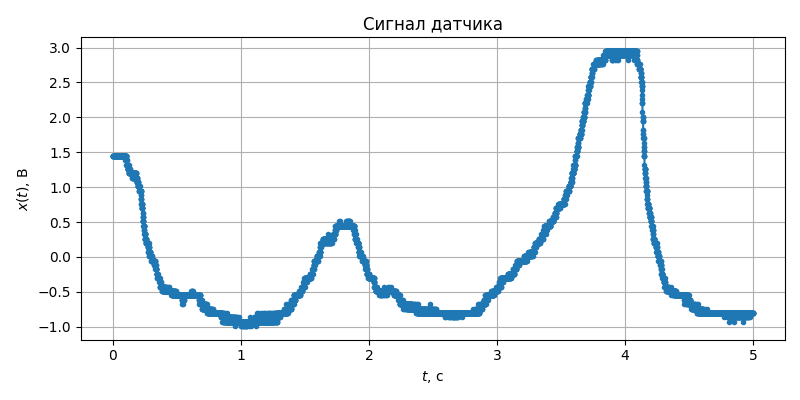

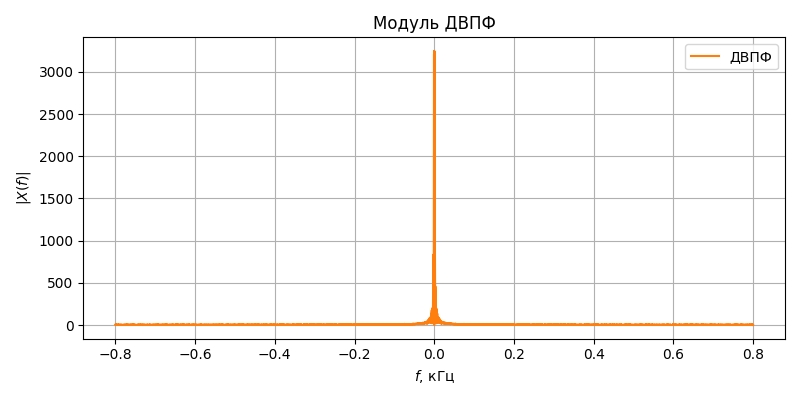

In [20]:
file_name = "Data/level_sensor.txt"
# Считывание сигнала
fs_2, x_2 = osc_read_txt(file=file_name)
x_2 = x_2 - x_2.mean()

plt.figure(figsize=[8, 4])
plt.title("Сигнал датчика")
k = np.arange(len(x_2))
plt.plot(k/fs_2, x_2, '.-')
plt.grid()
plt.xlabel("$t$, c")
plt.ylabel("$x(t)$, В")
plt.tight_layout()
plt.show()

# Вычисление ДВПФ
X_2_dtft = np.fft.fftshift(np.fft.fft(x_2))
f_2_dtft = np.fft.fftshift(np.fft.fftfreq(X_2_dtft.shape[0], d=1.0/fs_2))

# Модуль ДВПФ измерений с осциллографа.
plt.figure(figsize=[8, 4])
k = np.arange(len(x_2))
plt.plot(f_2_dtft/1e3, abs(X_2_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()


In [21]:
M = 30
y_2 = signal.convolve(x_2, h(M))
y_2


array([ 0.0483,  0.0966,  0.1449, ..., -0.0801, -0.0534, -0.0267])

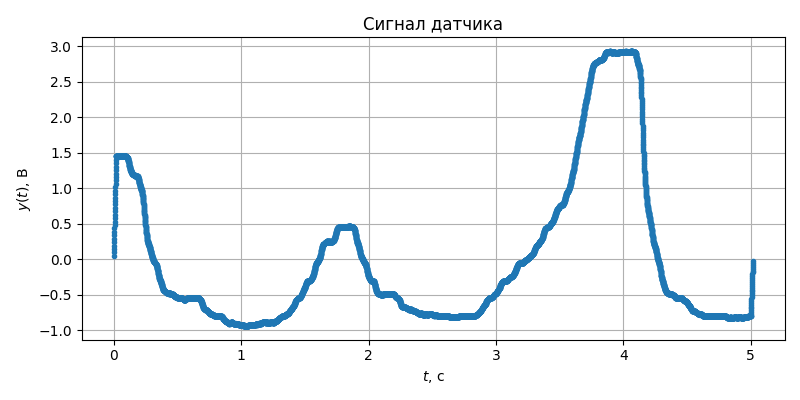

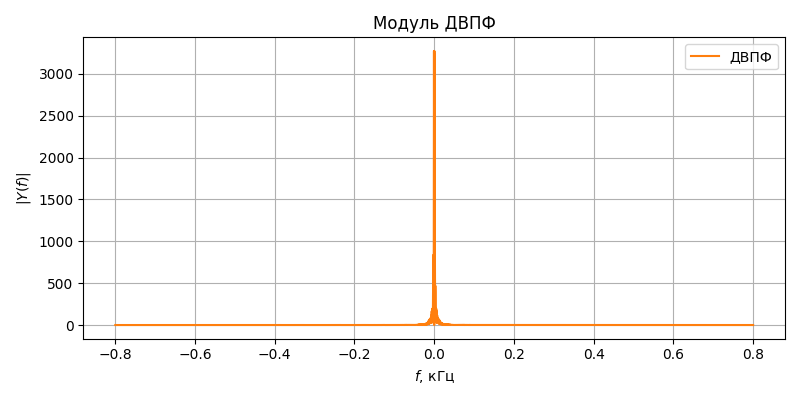

In [22]:
Y_2_dtft=scipy.fft.fftshift(scipy.fft.fft(y_2))
nu = -0.5 + np.linspace(0, 1, num=y_2.size)
Y_2_dtft

plt.figure(figsize=[8, 4])
plt.title("Сигнал датчика")
k = np.arange(len(y_2))
plt.plot(k/fs_2, y_2, '.-')
plt.grid()
plt.xlabel("$t$, c")
plt.ylabel("$y(t)$, В")
plt.tight_layout()
plt.show()

plt.figure(figsize=[8, 4])
k = np.arange(len(x_2))
plt.plot(nu*fs_2/1e3, abs(Y_2_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|Y(f)|$")
plt.legend()
plt.tight_layout()
plt.show()


Шум в измерениях может быть связан как с ошибками квантования, так и с природой самих сигналов: какие-то случайные изменения магнитного поля для датчика Холла, колебания уровня воды в попытке выровнять уровень после погружения датчика уровня воды.

Большие значения M сильно искажают форму сигнала, а маленькие значения слабо сглаживают сигнал и практически не убирают шумы.

## Задача 2.2. Двухкаскадный фильтр

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|----:|----:|-----:|----:|----:|----:|-----:|-----:|-----:|
| $a$ |  1 |  1 |  1 |  1 |  1 |  1 |  1 |  1 |  1 |  1 |
| $b$ |0.8 |0.7 |0.6 |0.8 |0.7 |0.6 |0.6 |0.8 |0.7 |0.6 |
| $c$ |0.5 |0.4 |0.3 |0.5 |0.3 |0.4 |0.3 |0.5 |0.3 |0.4 |

Рассмотрите двухкаскадный фильтр, каскады которого задаются следующими разностными уравнениями. 

1) $$y[k]=\dfrac{ax[k]+bx[k-M]+cx[k-2M]}{a+b+c}$$

где $a$, $b$, $c$ заданы в таблице с вариантами.

2) $$y[k]=\dfrac{x[k]+x[k-1]}{2}.$$

С помощью функции `signal.convolve` определите (для произвольного выбранного Вами коэффициента $M$), изменится ли импульсная характеристика от перестановки порядка каскадов. 

**Практическая часть (реверберация).**

Подайте на вход такого  фильтра аудиофайл (к примеру, запись речи длиной в несколько секунд). Коэффициент $M$ подберите самостоятельно. Определите, меняется ли выход системы от перестановки порядка каскадов.



In [23]:
a = 1
b = 0.7
c = 0.3

M = 10

A = a / (a + b + c)
B = b / (a + b + c)
C = c / (a + b + c)

h_1 = np.zeros(2 * M + 1)
h_1[0] = A
h_1[M] = B
h_1[2 * M] = C

h_2 = np.array([0.5, 0.5])


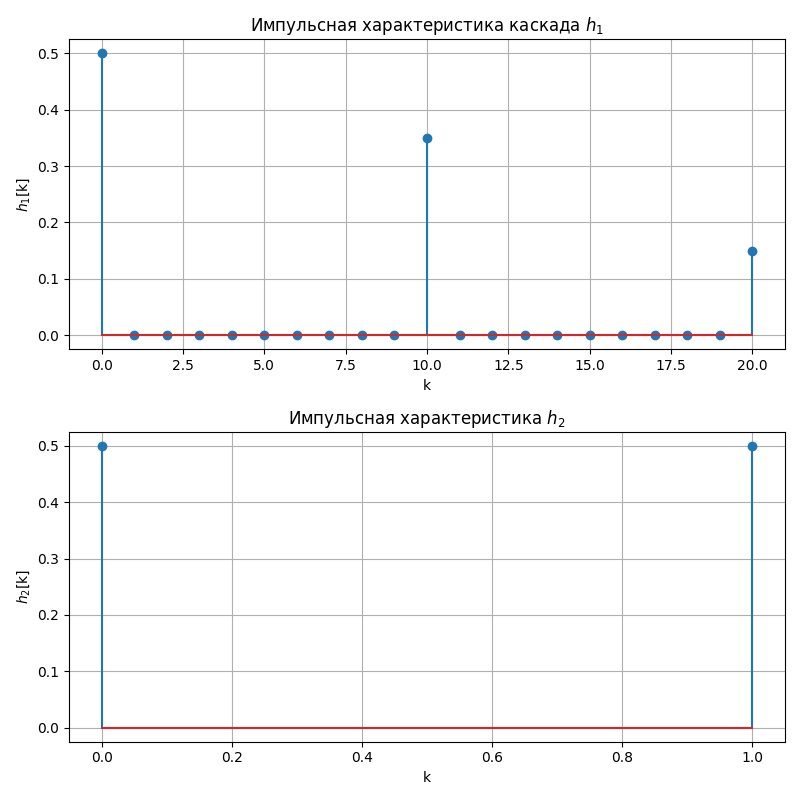

In [24]:
plt.figure(figsize=[8, 8], dpi=100)
plt.subplot(2, 1, 1)
plt.title("Импульсная характеристика каскада $h_1$")
plt.stem(np.arange(h_1.size), h_1)
plt.ylabel("$h_1$[k]")
plt.xlabel("k")
plt.grid()
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.title("Импульсная характеристика $h_2$")
plt.stem(np.arange(h_2.size), h_2)
plt.ylabel("$h_2$[k]")
plt.xlabel("k")
plt.grid()
plt.tight_layout()


In [25]:
h_12 = signal.convolve(h_1, h_2)
h_21 = signal.convolve(h_2, h_1)


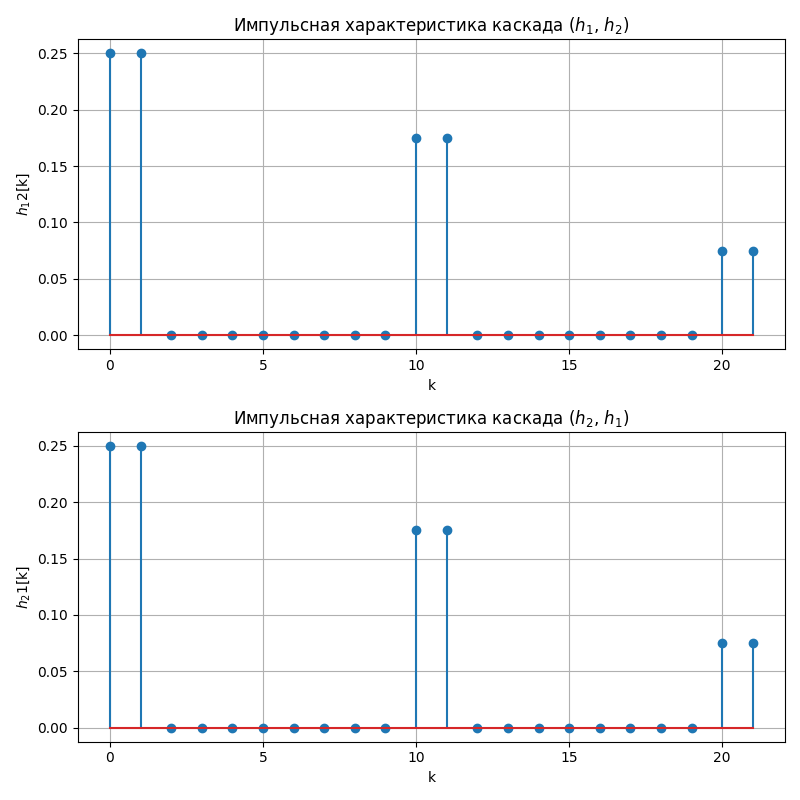

In [26]:
plt.figure(figsize=[8, 8], dpi=100)
plt.subplot(2, 1, 1)
plt.title("Импульсная характеристика каскада ($h_1$, $h_2$)")
plt.stem(np.arange(h_12.size), h_12)
plt.ylabel("$h_12$[k]")
plt.xlabel("k")
plt.grid()
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.title("Импульсная характеристика каскада ($h_2$, $h_1$)")
plt.stem(np.arange(h_21.size),h_21)
plt.ylabel("$h_21$[k]")
plt.xlabel("k")
plt.grid()
plt.tight_layout()
plt.show()


In [27]:
print(f"Max error: {max(abs(h_12 - h_21)):.1e}")


Max error: 0.0e+00


#### Практическая часть:

In [28]:
a = 1
b = 0.8
c = 0.5

M = 10000

A = a / (a + b + c)
B = b / (a + b + c)
C = c / (a + b + c)

h_1 = np.zeros(2 * M + 1)
h_1[0] = A
h_1[M] = B
h_1[2 * M] = C

h_2 = np.array([0.5, 0.5])


In [29]:
file_name = "Data/сливы.wav"
Audio(file_name)


In [30]:
fs, x1 = scipy.io.wavfile.read(file_name)

if x1.ndim > 1:
    x1 = x1[:,0]

x1, fs, x1.size


(array([ 277,  163,   84, ...,  298,  703, 1131], dtype=int16), 44100, 132300)

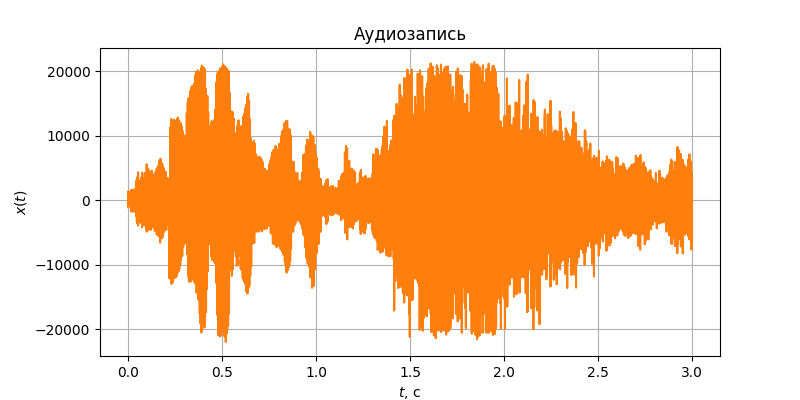

In [31]:
plt.figure(figsize=[8, 4])
plt.plot(np.arange(len(x1))/fs, x1, 'C1')
plt.xlabel(r'$t$, c')
plt.ylabel(r'$x(t)$')
plt.title('Аудиозапись')
plt.grid()


In [32]:
# Вычисление ДВПФ
X1_dtft = np.fft.fftshift(np.fft.fft(x1))
f1_dtft = np.fft.fftshift(np.fft.fftfreq(X1_dtft.shape[0], d=1.0/fs))

X1_dtft


array([-501.        -3.92901711e-10j, -438.76151875-6.37210429e+01j,
       -331.37872471-8.43269289e+01j, ..., -501.47267088-1.20669622e+02j,
       -331.37872471+8.43269289e+01j, -438.76151875+6.37210429e+01j])

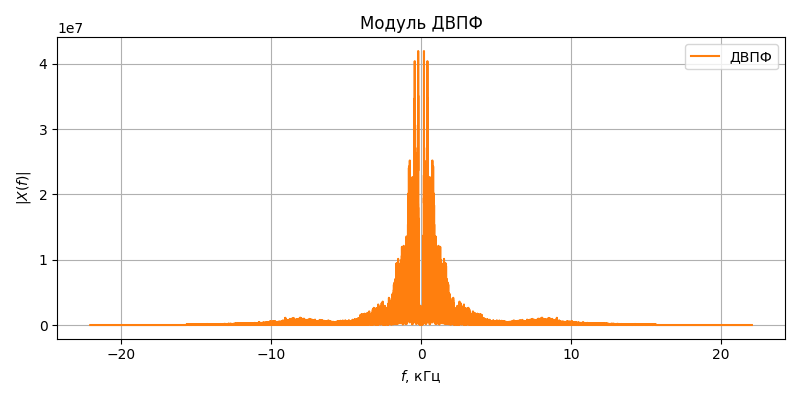

In [33]:
# Построение графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
k = np.arange(len(x1))
plt.plot(f1_dtft/1e3, abs(X1_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()


In [34]:
y12 = signal.convolve(signal.convolve(x1, h_1), h_2)
y21 = signal.convolve(signal.convolve(x1, h_2), h_1)


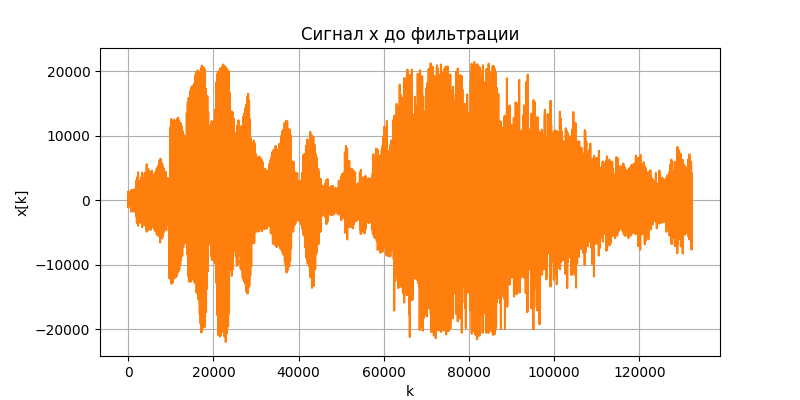

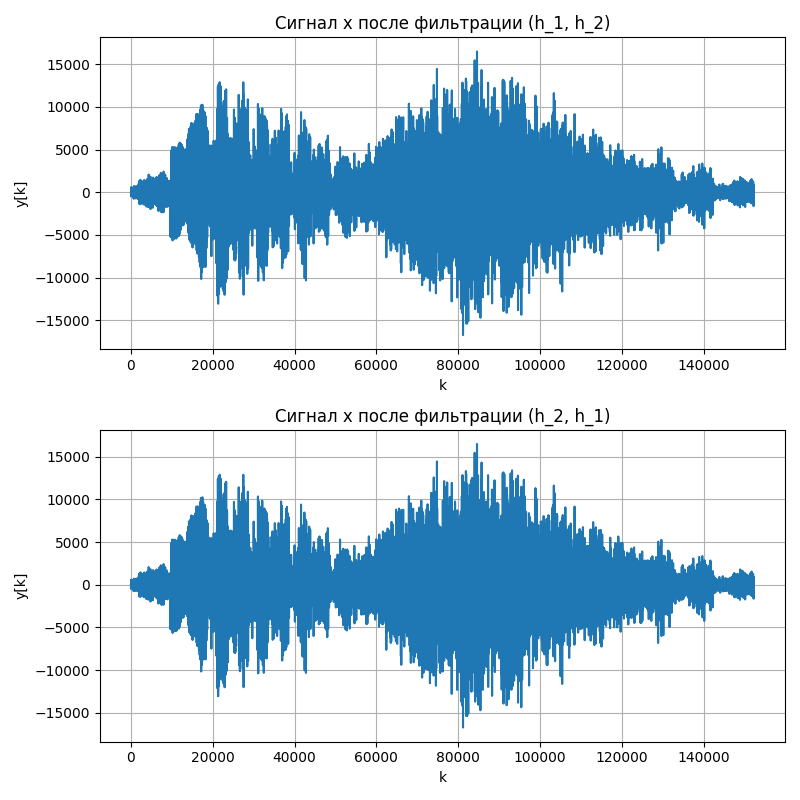

In [35]:
plt.figure(figsize=[8, 4], dpi=100)
plt.title("Сигнал x до фильтрации")
plt.plot(np.arange(len(x1)), x1, 'C1')
plt.grid()
plt.ylabel("x[k]")
plt.xlabel("k")

plt.figure(figsize=[8, 8], dpi=100)
plt.subplot(2, 1, 1)
plt.title("Сигнал x после фильтрации (h_1, h_2)")
plt.plot(np.arange(y12.size), y12)
plt.ylabel("y[k]")
plt.xlabel("k")
plt.grid()
plt.tight_layout()


plt.subplot(2, 1, 2)
plt.title("Сигнал x после фильтрации (h_2, h_1)")
plt.plot(np.arange(y21.size), y21)
plt.ylabel("y[k]")
plt.xlabel("k")
plt.grid()
plt.tight_layout()


/tmp/ipykernel_165525/3027362314.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=[8, 4])


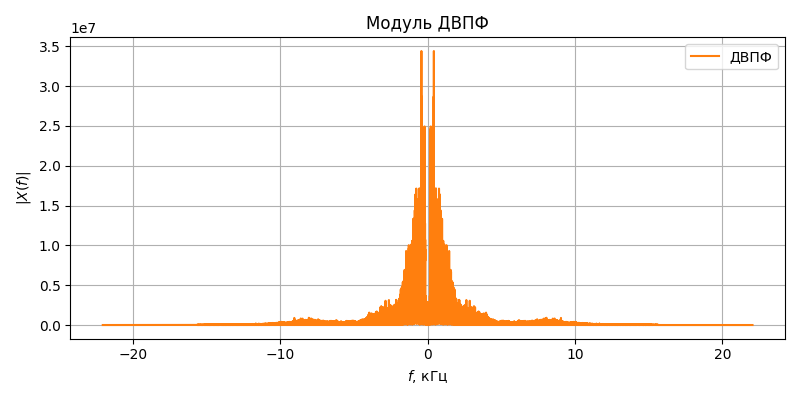

In [36]:
# Вычисление ДВПФ
Y_dtft = np.fft.fftshift(np.fft.fft(y12))
f_dtft = np.fft.fftshift(np.fft.fftfreq(Y_dtft.shape[0], d=1.0/fs))

# Построение графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
k = np.arange(len(y12))
plt.plot(f_dtft/1e3, abs(Y_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()


In [37]:
print(f"Max error: {max(abs(y12 - y21)):.1e}")


Max error: 9.1e-12


In [38]:
# scipy.io.wavfile.write(filename='./filtered.wav', rate=fs, data=np.asarray(y21, dtype=np.int16))


In [39]:
Audio(y21, rate=fs)


In [40]:
Audio(y12, rate=fs)


# Модуль 3. Аппроксимация идеальных частотно-избирательных фильтров и явление Гиббса

## Задача 3.1. Явление Гиббса для каузальной аппроксимации ИФНЧ.

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|  $\nu_c$  |0.1 |0.2 |0.3 |0.1 |0.2 |0.3 |0.2 |0.3 |0.1 | 0.2 |
|    $N$    | 30 | 20 | 30 | 20 | 30 | 20 | 24 | 22 | 26 | 28 |

Рассмотрите фильтр с импульсной характеристикой
$$
h[k] =
\left\{\begin{array}{l}
\dfrac{\sin(2\pi\nu_c (k-N))}{\pi (k-N)}, 0\le k \le 2N-1
\\
0, \; \text{при других } k.
\end{array}\right.
$$
для случая $\nu_c,\; N$ из варианта. 

Вычислите с помощью моделирования и постройте график АЧХ этого фильтра.  
Как изменяется АЧХ с ростом $N$ при фиксированной частоте среза $\nu_c$?

**Практическая часть.**
Практическая часть выполняется в одном из двух вариантов по выбору студента. 

**Вариант А (резисторный сумматор)**. Используя схему сумматора на резисторах получите сумму двух синусоидальных сигналов, частота одного из которых попадает в полосу пропускания фильтра, а второго - в полосу задержки. Подайте данный сигнал на вход данного фильтра. Сравните спектр сигнала до и после фильтрации.

**Вариант Б (минусовая фонограмма)**. Запишите аудиофайл, содержащий высокие и низкие частоты. Пропустите сигнал через фильтр. Сравните запись звука и спектр сигнала до и после фильтрации.


In [41]:
nu_c = 0.1
N = 26


In [42]:
def h_0(t: float, nu_c: float) -> float:
    if abs(t) < 1e-10:
        return 2.0 * nu_c
    return np.sin(2 * np.pi * nu_c * t) / (np.pi * t)

def h_0_shifted(k: int, nu_c: float, N: int) -> float:
    if 0 <= k <= 2 * N:
        return h_0(k - N, nu_c)
    return 0.0


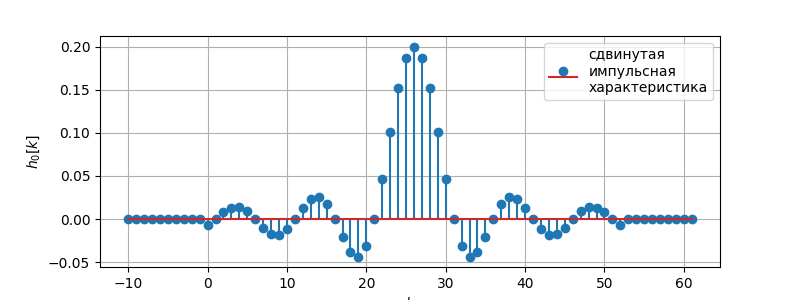

In [43]:
plt.figure(figsize=[8, 3])
k = np.arange(-10, 2 * N + 10, 1)
plt.stem(k, [h_0_shifted(k1, nu_c, N) for k1 in k], label="сдвинутая\nимпульсная\nхарактеристика")
plt.xlabel("$k$")
plt.ylabel("$h_0[k]$")
plt.grid()
plt.legend()
plt.show()


In [44]:
def path_sum(N: int, nu: np.array, nu_c: float) -> np.array:
    k = np.arange(-N, N + 1, 1)
    H_part=np.zeros_like(nu, dtype=complex)
    for k1 in k:
        H_part += h_0(k1, nu_c) * np.exp(-1j * 2 * np.pi * nu * k1)
    return H_part

def plot_path_sum(N: int, nu_c: float) -> None:
    k = np.arange(0, 2 * N, 1)
    nu = np.linspace(-0.5, 0.5, 2048)

    plt.figure(figsize=[8, 4])
    plt.step([-0.5, -nu_c, 0, nu_c, 0.5], [0, 0, 1, 1, 0], 'C1-')
    plt.plot(nu, path_sum(N, nu, nu_c).real, 'b')
    plt.xticks([-0.5, -nu_c, 0, nu_c, 0.5])
    plt.xlim([-0.5, 0.5])
    plt.xlabel("$\\nu$")
    plt.ylabel("$H_0(\\nu)$, $H_0(\\nu, N)$")
    plt.title("Частичные суммы ряда")
    plt.grid()
    plt.show()


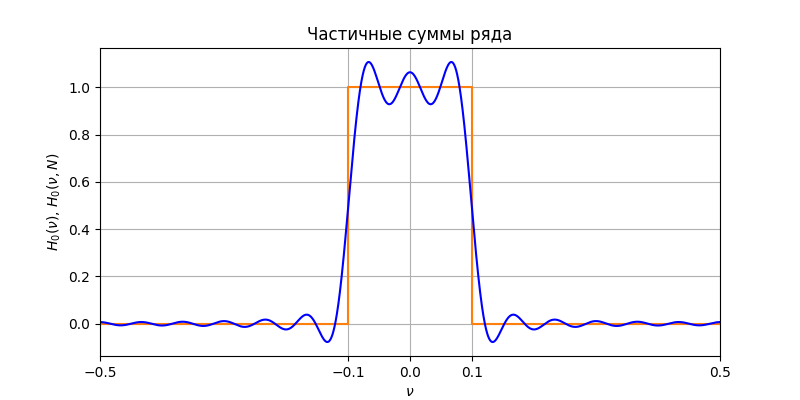

In [45]:
plot_path_sum(15, nu_c)


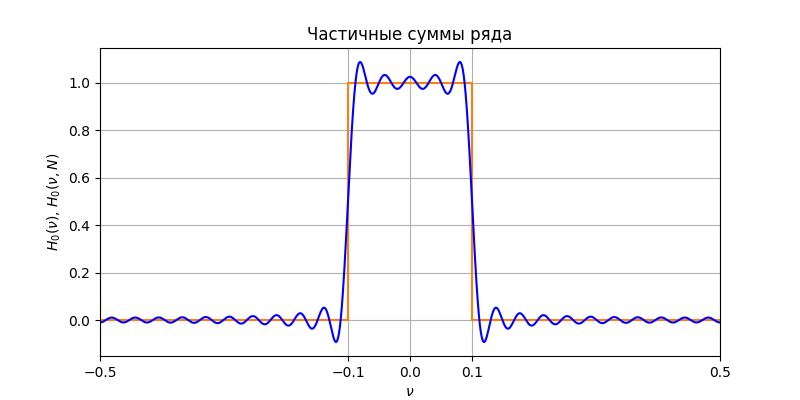

In [46]:
plot_path_sum(N, nu_c)


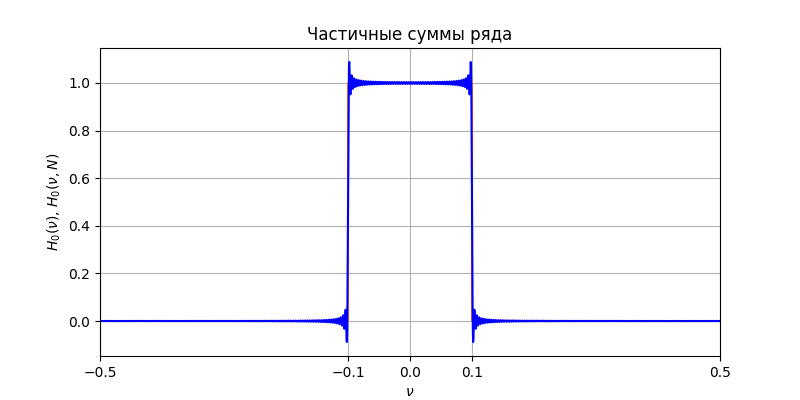

In [47]:
plot_path_sum(N * 10, nu_c)


С ростом $N$ АЧХ сходится к прямоугольной АЧХ соответствующего идеального фильтра. Однако вблизи частоты среза наблюдается не исчезающие при росте $N$ всплески АЧХ, превышающие ожидаемый уровень на величину до (приблизительно) $10\%$.

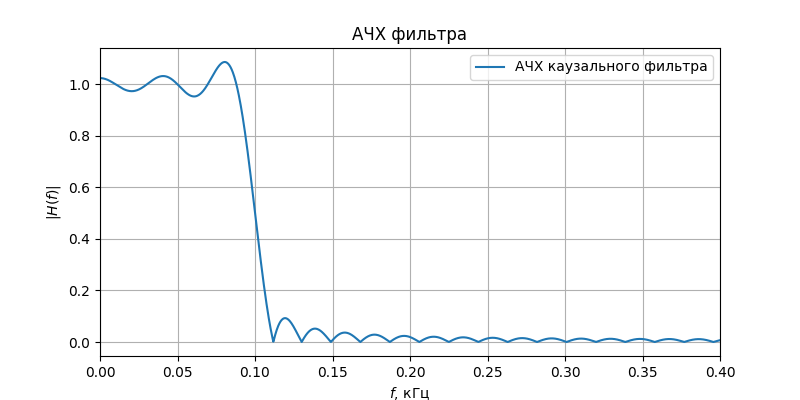

In [48]:
theta, H = signal.freqz(b=[h_0_shifted(k1, nu_c, N) for k1 in k], worN=2**12, whole=True)
nu = theta/(2*np.pi) - 0.5
H = np.fft.fftshift(H)
H = H - H.mean()

plt.figure(figsize=[8, 4])
plt.plot(nu*1, abs(H), label="АЧХ каузального фильтра")

plt.xlim([0, 0.4])
plt.title("АЧХ фильтра")
plt.xlabel("$f$, кГц")
plt.ylabel("$|H(f)|$")
plt.grid()
plt.legend()
plt.show()


#### Практическая часть:

In [49]:
filename = "Data/sample-12s.wav"
Audio(filename)


In [50]:
fs, x = scipy.io.wavfile.read(filename)

if x.ndim > 1:
    x = x[:,0]

x, fs, x.size


(array([-1, -1,  0, ..., -2,  1,  1], dtype=int16), 44100, 563712)

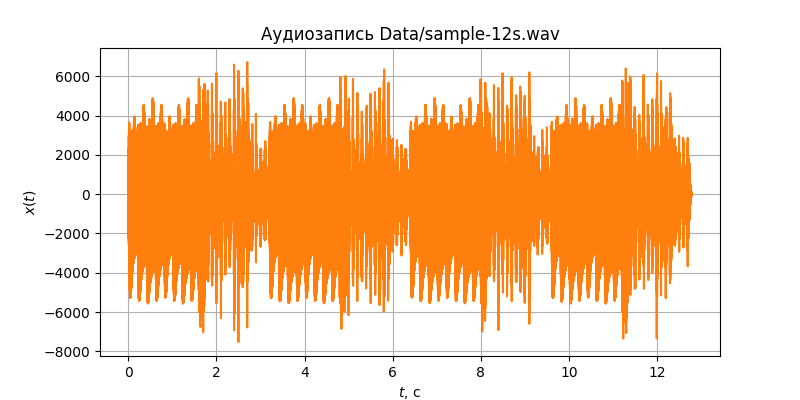

In [51]:
plt.figure(figsize=[8, 4])
plt.plot(np.arange(len(x))/fs, x, 'C1')
plt.xlabel(r'$t$, c')
plt.ylabel(r'$x(t)$')
plt.title(f"Аудиозапись {filename}")
plt.grid()


In [52]:
# Вычисление ДВПФ
X_dtft = np.fft.fftshift(np.fft.fft(x))
f_dtft = np.fft.fftshift(np.fft.fftfreq(X_dtft.shape[0], d=1.0/fs))

X_dtft


array([  63.        +9.18589649e-11j, -235.5822272 -4.64244224e+01j,
        -73.81556746+3.62538758e+01j, ...,   17.48620996+1.62925747e+02j,
        -73.81556746-3.62538758e+01j, -235.5822272 +4.64244224e+01j])

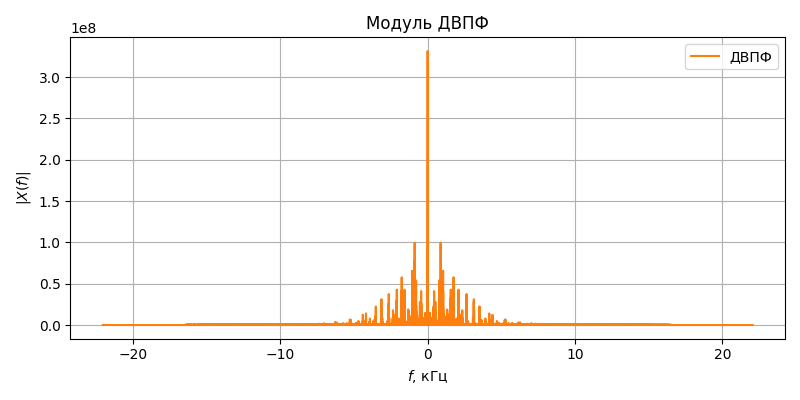

In [53]:
# Построение графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
k = np.arange(len(x))
plt.plot(f_dtft/1e3, abs(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel(r"$f$, кГц")
plt.ylabel(r"$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()


In [54]:
k_filter = np.arange(0, 2 * N)
y = signal.convolve(x, [h_0_shifted(k1, nu_c, N) for k1 in k_filter])
y


array([ 7.19607141e-03,  7.19607141e-03, -7.79574403e-03, ...,
        2.09579480e-02,  7.79574403e-03,  7.79634367e-18])

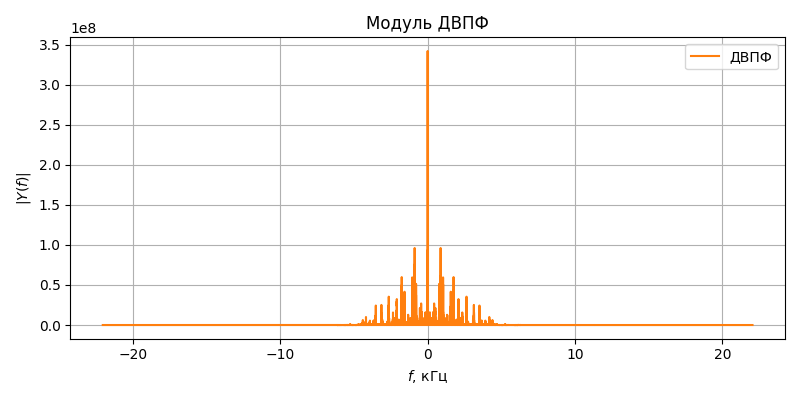

In [55]:
Y_dtft = scipy.fft.fftshift(scipy.fft.fft(y))
nu = -0.5 + np.linspace(0, 1, num=y.size)

plt.figure(figsize=[8, 4])
k = np.arange(len(x))
plt.plot(nu*fs/1e3, abs(Y_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|Y(f)|$")
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
Audio(y, rate=fs)


## Задача 3.2.  Аппроксимация фильтра с заданной частотной характеристикой с помощью ДВПФ.   

Определить импульсную характеристику $h_{ideal}[k]$ фильтра, частотная характеристика которого является действительной функцией частоты и представлена на рисунке. 

Рассмотреть фильтр, импульсная характеристика которого в отличии от $h_{ideal}[k]$  усечена до $2N$ отсчетов и сдвинута на $N$ отсчетов вправо. С помощью моделирования определить и построить график АЧХ. Сравнить АЧХ обоих фильтров.

Рисунок генерируется с помощью функции `task_3_2(familyname)` (приведенной ниже), где `familyname` – фамилия. 

**Практическая часть (АМ-сигнал).**

С помощью амплитудной модуляции получите сигнал с тремя гармоническими компонентами, лежащими в полосах частот с разными коэффициентами пропускания.  Пропустите сигнал через данный фильтр. Сравните сигнал и его спектр до и после фильтрации. 

In [57]:
def task_3_2(familyname):
    variant = int(hash(familyname))%10 + 1
    # hash() выдаёт недетерминированные между запусками результаты начиная с python 3.3
    nu_c1 = [0.2, 0.15, 0.15, 0.1, 0.15, 0.15, 0.2, 0.15, 0.15, 0.1]
    amp1 = [1,  0.4, 0.2, 1, 1, 0.6, 0.3, 0.2, 1, 1]
    nu_c2 = [0.4, 0.35, 0.4,  0.3,  0.35,  0.4, 0.4,  0.3,  0.35,  0.4]
    amp2 = [0.4, 1, 1, 0.4, 0.7,  1, 1, 1, 0.4, 0.7]
    def H_val(nu, n):
        return amp1[n] if abs(nu)<=nu_c1[n] else amp2[n] if abs(nu)<=nu_c2[n] else 0.0
    nu=np.arange(-0.5, 0.5, 0.001)
    plt.figure(figsize=[6, 2], dpi=140)
    plt.plot(nu, [H_val(x, variant-1) for x in nu] ,'g-')
    plt.xticks([-0.5, -nu_c2[variant-1], -nu_c1[variant-1], 0, nu_c1[variant-1], nu_c2[variant-1], 0.5])
    plt.grid()
    plt.yticks([0, min(amp1[variant-1],amp2[variant-1]), 1])
    plt.xlim([-0.5, 0.5])
    plt.xlabel("Нормированнная частота, $\\nu$")
    plt.ylabel("$H(\\nu)$")
    plt.title("Вариант %i" %variant)
    plt.tight_layout()
    plt.show()


Пример вывода задания.

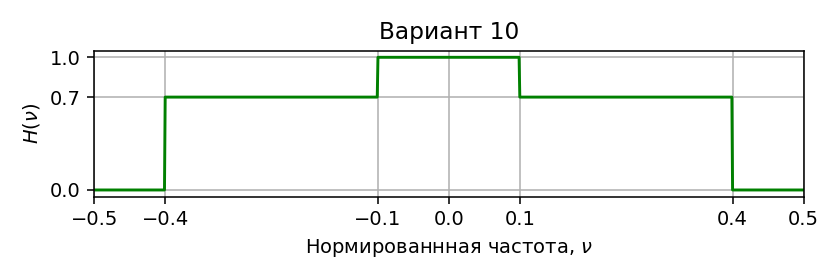

In [58]:
task_3_2(familyname="Цедрик")


Импульсную характеристику данного идеального фильтра можно представить аналитически как сумму импульсных характеристик пары более простых фильтров:

$$h_{ideal}[k] = h_1[k] + h_2[k] = 0.7 \dfrac{\sin(2 \pi \nu_{c1} k)}{\pi k} + 0.3\dfrac{\sin(2\pi \nu_{c2} k)}{\pi k}$$

Где $\nu_{c1} = 0.4 \text{, } \nu_{c2} = 0.1$

После сдвига на $N$ тактов дискретизации и усечения до $2N$ отсчетов получим импульсную характеристику каузального фильтра:
$$ h[k] = 0.7 \dfrac{\sin(2 \pi \nu_{c1} (k-N))}{\pi (k-N)} + 0.3 \dfrac{\sin(2 \pi \nu_{c2} (k-N))}{\pi (k-N)}, k=0, \,1, \, \dots,  2N-1$$

In [ ]:
N = 30
nu_c_1 = 0.4
nu_c_2 = 0.1
k = np.arange(-N, N, 1)

def h_0(k, N):
    if (k - N) != 0:
        return 0.7*np.sin(2*np.pi*nu_c_1*(k - N))/(np.pi*(k - N)) + 0.3*np.sin(2*np.pi*nu_c_2*(k - N))/(np.pi*(k - N))
    return 2*0.7*nu_c_1 + 2*0.3*nu_c_2


In [69]:
def plot_ampl_freq_response(N):
    k = np.arange(0, 2*N, 1)
    h = np.array([h_0(k1, N) for k1 in k])
    theta, H = signal.freqz(b=h, worN=2**16, whole=True)
    nu = theta/(2*np.pi)-0.5
    H = np.fft.fftshift(H)

    plt.figure(figsize=[8, 3])
    dict_ideal_frequency_response = {-0.5:0, -0.4:0, -0.1:0.7, 0.1:1, 0.4:0.7, 0.5:0}
    plt.step(dict_ideal_frequency_response.keys(),  dict_ideal_frequency_response.values(), 'C1-', label="АЧХ\nидеального\nфильтра")
    plt.plot(nu, abs(H), label="АЧХ\nсинтезированного\nфильтра")
    plt.legend(ncols=1, loc='upper right')
    plt.xlim([-0.5, 0.5])
    plt.xticks(list(dict_ideal_frequency_response.keys()))
    plt.title("АЧХ фильтра")
    plt.xlabel("$\\nu$")
    plt.ylabel("$|H(\\nu)|$")
    plt.grid()
    plt.tight_layout()
    plt.show()


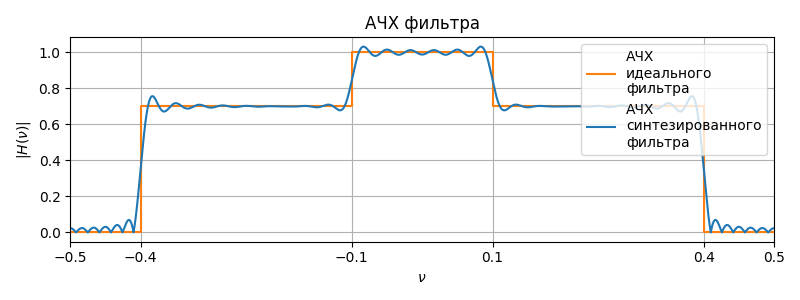

In [70]:
plot_ampl_freq_response(N)


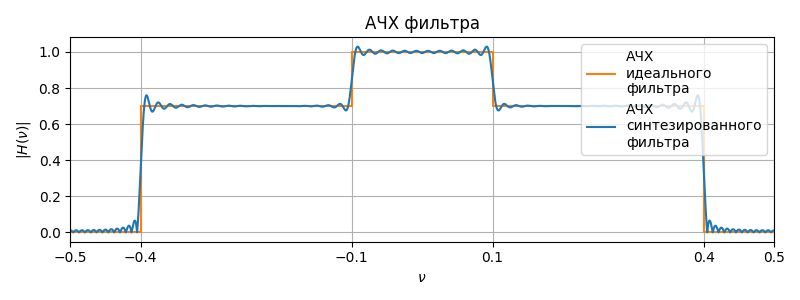

In [71]:
plot_ampl_freq_response(N * 2)


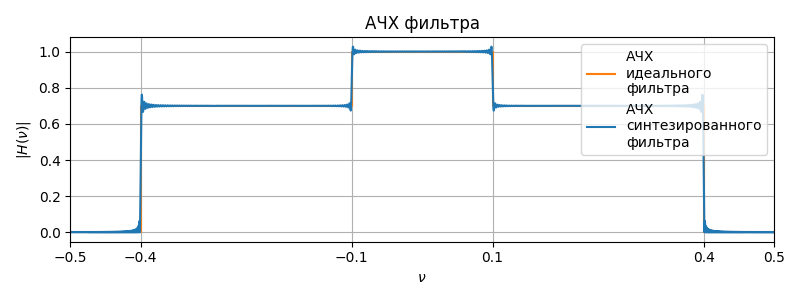

In [72]:
plot_ampl_freq_response(N * 10)


С ростом $N$ АЧХ сходится к прямоугольной АЧХ соответствующего идеального фильтра. Однако вблизи частоты среза наблюдается не исчезающие при росте $N$ всплески АЧХ, превышающие ожидаемый уровень на величину до (приблизительно) $10\%$.

#### Практическая часть:

In [76]:
file_name = "Data/gosha/3-2.txt"
# Считывание сигнала
fs, x = osc_read_txt(file=file_name)
x = x - x.mean()

# Вычисление ДВПФ
X_dtft = np.fft.fftshift(np.fft.fft(x))
f_dtft = np.fft.fftshift(np.fft.fftfreq(X_dtft.shape[0], d=1.0/fs))


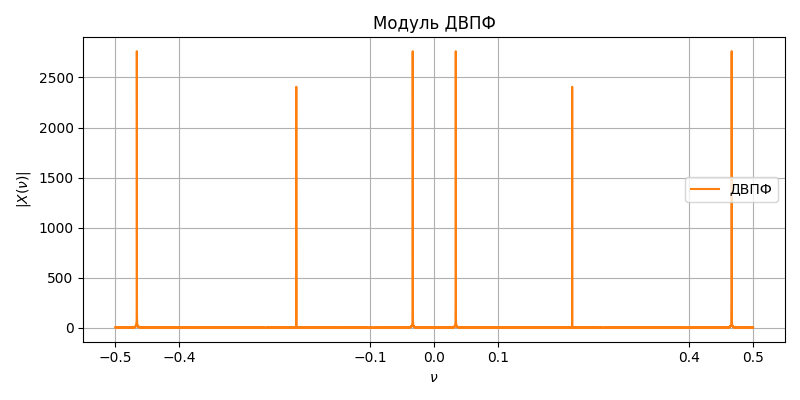

In [80]:
# Модуль ДВПФ измерений с осциллографа.
plt.figure(figsize=[8, 4])
k = np.arange(len(x))
plt.plot(f_dtft/fs, abs(X_dtft), 'C1', label="ДВПФ")

plt.grid()
plt.title("Модуль ДВПФ")
plt.xticks([-0.5, -0.4, -0.1, 0, 0.1, 0.4, 0.5])
plt.xlabel(r"$\nu$")
plt.ylabel(r"$|X(\nu)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()


In [81]:
y = signal.convolve(x, [h_0(k1, N) for k1 in k])
y


array([-1.91846539e-16, -6.97226816e-03,  6.97568818e-03, ...,
        1.71636131e-05, -1.66389421e-05,  6.90974730e-06])

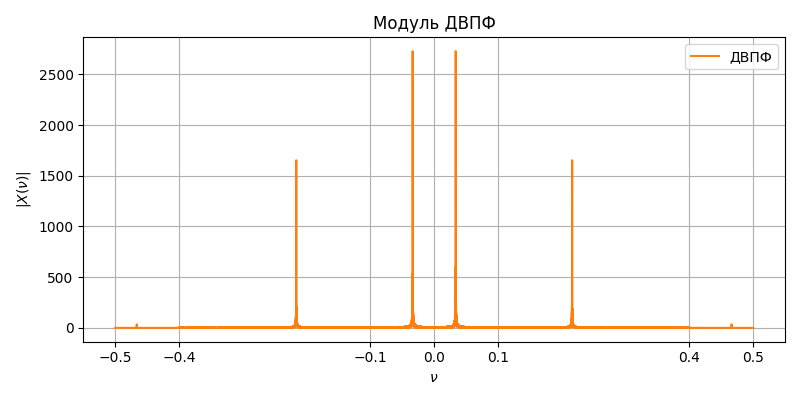

In [83]:
Y_dtft=scipy.fft.fftshift(scipy.fft.fft(y))
nu = -0.5 + np.linspace(0, 1, num=y.size)
Y_dtft

plt.figure(figsize=[8, 4])
k = np.arange(len(x))
plt.plot(nu, abs(Y_dtft), 'C1', label="ДВПФ")
plt.xticks([-0.5, -0.4, -0.1, 0, 0.1, 0.4, 0.5])
plt.grid()
plt.title("Модуль ДВПФ")
plt.xlabel(r"$\nu$")
plt.ylabel(r"$|X(\nu)|$")
plt.legend()
plt.tight_layout()
plt.show()


Наблюдаемый спектр соответствует произведению спектров фильтра и снятого с осциллографа сигнала.

# Модуль 4. Графическое моделирование динамических систем.

## Задача 4.1. Моделирование цифрового фильтра в Engee/РДС.

Для выполнения данного задания нужно самостоятельно выбрать цифровой фильтр. Затем в графическом режиме построить его цифровую модель в системе Engee либо РДС и промоделировать работу фильтра на примере одного из возможных выходных сигналов. Обосновать результаты. 

В качестве фильтра был выбран фильтр скользящего среднего с M = 5

![Схема](Data/scheme.png)

![Импульсная характеристика](Data/h.png)

![Синус](Data/sine.png)

![Синус после фильтра](Data/filtered_sine.png)